In [456]:
import pandas as pd
import numpy as np
import time

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import phik

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import make_scorer, average_precision_score

import joblib

### Анализ данных и отбор признаков

Загрузим датасет и выведем первые 10 записей, чтобы посмотреть на типы данных и наполнение

In [457]:
credit_data_raw = pd.read_csv(r'E:/проекты/Хакатончик/Data/credit_scoring_data.csv')
print(credit_data_raw.shape)

(100000, 28)


C:\Users\Влад\AppData\Local\Temp\ipykernel_25464\1940036208.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  credit_data_raw = pd.read_csv(r'E:/проекты/Хакатончик/Data/credit_scoring_data.csv')


In [458]:
print(credit_data_raw.head())

       ID Customer_ID     Month           Name   Age          SSN Occupation Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  Interest_Rate Num_of_Loan                                       Type_of_Loan  Delay_from_due_date Num_of_Delayed_Payment Changed_Credit_Limit  Num_Credit_Inquiries Credit_Mix Outstanding_Debt  Credit_Utilization_Ratio     Credit_History_Age Payment_of_Min_Amount  Total_EMI_per_month Amount_invested_monthly                 Payment_Behaviour     Monthly_Balance Credit_Score
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist      19114.12            1824.843333                  3                4              3           4  Auto Loan, Credit-Builder Loan, Personal Loan,...                    3                      7                11.27                   4.0          _           809.98                 26.822620  22 Years and 1 Months                    No            49.574949       80.41529543900253   High_spent_Sm

In [459]:
print(credit_data_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Столбцы имеют не корректные названия, поэтому переименуем их

In [460]:
credit_data_raw.columns = credit_data_raw.columns.str.lower()
print(credit_data_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        100000 non-null  object 
 1   customer_id               100000 non-null  object 
 2   month                     100000 non-null  object 
 3   name                      90015 non-null   object 
 4   age                       100000 non-null  object 
 5   ssn                       100000 non-null  object 
 6   occupation                100000 non-null  object 
 7   annual_income             100000 non-null  object 
 8   monthly_inhand_salary     84998 non-null   float64
 9   num_bank_accounts         100000 non-null  int64  
 10  num_credit_card           100000 non-null  int64  
 11  interest_rate             100000 non-null  int64  
 12  num_of_loan               100000 non-null  object 
 13  type_of_loan              88592 non-null   ob

Также некоторые столбцы имеют не верный тип данных

In [461]:
num_cols = ['annual_income', 'monthly_inhand_salary', 
            'outstanding_debt', 'monthly_balance', 'age',
              'num_of_loan', 'num_of_delayed_payment', 'amount_invested_monthly']

for col in num_cols:
    credit_data_raw[col] = pd.to_numeric(credit_data_raw[col], errors='coerce')


У нас есть неинформативные столбцы id и customer_id, удалим их датасета

In [462]:
credit_data_raw.drop(columns=['id', 'customer_id'], axis=1, inplace=True)



#### Поиск аномалий  

Проверим данные на наличие аномальных значений

In [463]:
def num_ditribution(data, xcols, titles, xlables, figsize, minus):
    fig, axs = plt.subplots(len(xcols), 2, figsize=figsize)
    for i in range(len(xcols)):
        sns.histplot(data=data, x=xcols[i], bins=20, ax=axs[i, 0])
        axs[i, 0].set_xlabel(xlables[i])
        axs[i, 0].set_ylabel('Количество')
        axs[i, 0].set_title(titles[i])

        sns.boxplot(x=data[xcols[i]], orient='h', ax=axs[i, 1])
        axs[i, 1].set_xlabel(xlables[i])
        axs[i, 1].set_title(titles[i])

    plt.subplots_adjust(wspace=0.3, hspace=0.9)
    plt.show()

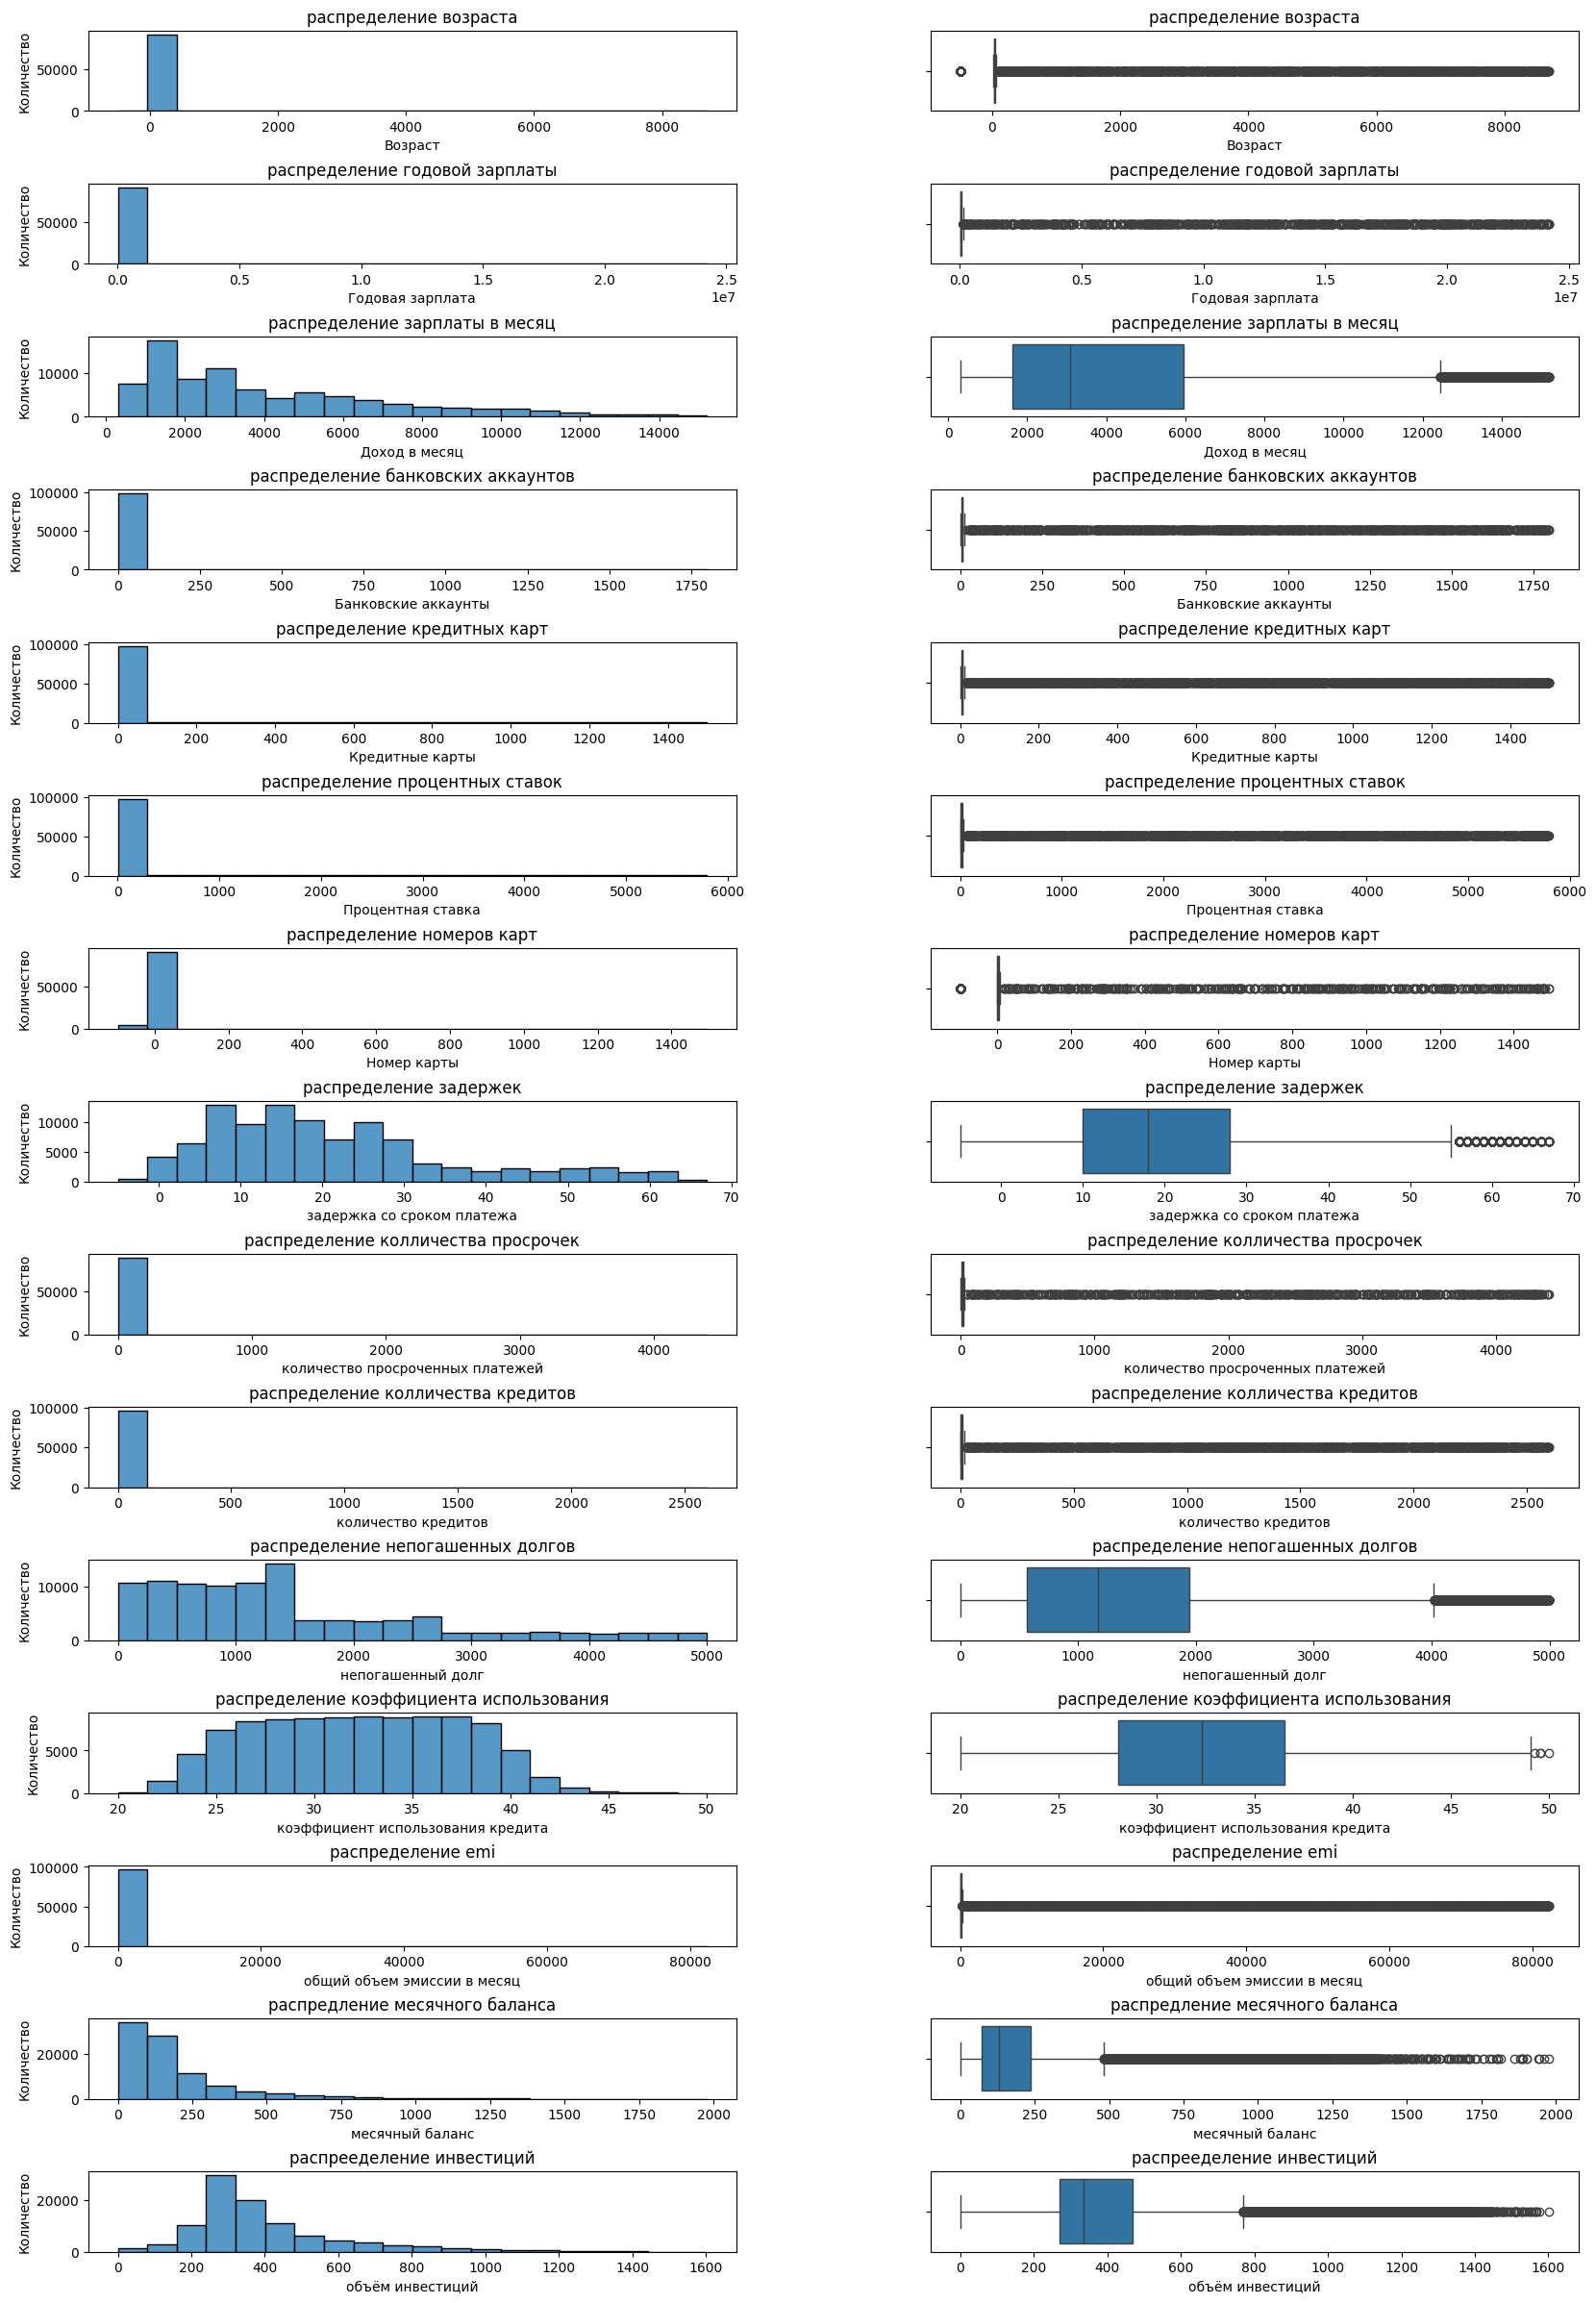

['age', 'annual_income', 'monthly_inhand_salary', 'num_bank_accounts', 'num_credit_card', 'interest_rate', 'num_of_loan', 'delay_from_due_date', 'num_of_delayed_payment', 'num_credit_inquiries', 'outstanding_debt', 'credit_utilization_ratio', 'total_emi_per_month', 'amount_invested_monthly', 'monthly_balance']


In [464]:
num_cols = [x for x in credit_data_raw.select_dtypes(include=['int64', 'float64'])]
credit_scores_xlabels = [
    'Возраст',
    'Годовая зарплата',
    'Доход в месяц',
    'Банковские аккаунты',
    'Кредитные карты',
    'Процентная ставка',
    'Номер карты',
    'задержка со сроком платежа',
    'количество просроченных платежей',
    'количество кредитов',
    'непогашенный долг',
    'коэффициент использования кредита',
    'общий объем эмиссии в месяц',
    'месячный баланс',
    'объём инвестиций'
]

credit_titles = [
    'распределение возраста',
    'распределение годовой зарплаты',
    'распределение зарплаты в месяц',
    'распределение банковских аккаунтов',
    'распределение кредитных карт',
    'распределение процентных ставок',
    'распределение номеров карт',
    'распределение задержек',
    'распределение колличества просрочек',
    'распределение колличества кредитов',
    'распределение непогашенных долгов',
    'распределение коэффициента использования',
    'распределение emi',
    'распредление месячного баланса',
    'распрееделение инвестиций'
]

num_ditribution(credit_data_raw, num_cols, credit_titles, credit_scores_xlabels, (20, 30), 1)
print(num_cols)

In [465]:
credit_data_raw = credit_data_raw[(credit_data_raw['age'] > 18) & (credit_data_raw['age'] < 70)]
credit_data_raw = credit_data_raw[credit_data_raw['num_of_delayed_payment'] >= 0]

credit_data_raw.drop(columns=['num_of_loan', 'ssn'], axis=1, inplace=True)


In [466]:
print((credit_data_raw.isna().sum() / len(credit_data_raw) * 100))

month                        0.000000
name                         9.997098
age                          0.000000
occupation                   0.000000
annual_income                7.022242
monthly_inhand_salary       15.018073
num_bank_accounts            0.000000
num_credit_card              0.000000
interest_rate                0.000000
type_of_loan                11.942957
delay_from_due_date          0.000000
num_of_delayed_payment       0.000000
changed_credit_limit         0.000000
num_credit_inquiries         1.964328
credit_mix                   0.000000
outstanding_debt             1.026358
credit_utilization_ratio     0.000000
credit_history_age           9.040659
payment_of_min_amount        0.000000
total_emi_per_month          0.000000
amount_invested_monthly      8.829582
payment_behaviour            0.000000
monthly_balance              1.176750
credit_score                 0.000000
dtype: float64


In [467]:
credit_data_raw.drop(columns=['name', 'type_of_loan'], axis=1, inplace=True)
credit_data_raw['monthly_inhand_salary'].fillna(credit_data_raw['monthly_inhand_salary'].median(), inplace=True)
credit_data_raw['amount_invested_monthly'].fillna(credit_data_raw['amount_invested_monthly'].median(), inplace=True)

C:\Users\Влад\AppData\Local\Temp\ipykernel_25464\838928482.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  credit_data_raw['monthly_inhand_salary'].fillna(credit_data_raw['monthly_inhand_salary'].median(), inplace=True)
C:\Users\Влад\AppData\Local\Temp\ipykernel_25464\838928482.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on wh

In [468]:
credit_data_raw.drop_duplicates(inplace=True)


In [469]:


credit_data_raw['credit_score'] = credit_data_raw['credit_score'].map({
     'Good': 1,
     'Standard': 1,
     'Poor': 0,
})


corr_matrix = credit_data_raw.corr(numeric_only=True)
corr_matrix['credit_score'].sort_values(ascending=False)
# plt.figure(figsize=(20, 30))
# sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
# plt.title('PhiK Correlation Matrix')
# plt.show()

credit_score                1.000000
monthly_balance             0.165596
monthly_inhand_salary       0.145638
amount_invested_monthly     0.106650
age                         0.104499
credit_utilization_ratio    0.035772
annual_income               0.010841
total_emi_per_month         0.001875
interest_rate              -0.002591
num_of_delayed_payment     -0.004955
num_credit_card            -0.005471
num_bank_accounts          -0.007920
num_credit_inquiries       -0.010846
outstanding_debt           -0.362680
delay_from_due_date        -0.371738
Name: credit_score, dtype: float64

Удалим из датасета признаки которые слабо коррелируют с таргетом это столбцы: annual_income, total_emi_per_month, interest_rate, num_of_delayed_payment, num_credit_card, num_bank_accounts, num_credit_inquiries, credit_utilization_ratio

In [470]:
credit_data_raw.drop(columns=['annual_income', 'total_emi_per_month', 'interest_rate', 
                              'num_of_delayed_payment', 'num_credit_card', 'num_bank_accounts',
                              'num_credit_inquiries', 'credit_utilization_ratio', 'credit_history_age', 
                              'month', 'payment_of_min_amount', 'changed_credit_limit'], axis=1, inplace=True)


In [471]:
credit_data_raw.rename(columns={'credit_score': 'target'}, inplace=True)
credit_data = credit_data_raw
print(credit_data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 75802 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      75802 non-null  float64
 1   occupation               75802 non-null  object 
 2   monthly_inhand_salary    75802 non-null  float64
 3   delay_from_due_date      75802 non-null  int64  
 4   credit_mix               75802 non-null  object 
 5   outstanding_debt         75024 non-null  float64
 6   amount_invested_monthly  75802 non-null  float64
 7   payment_behaviour        75802 non-null  object 
 8   monthly_balance          74910 non-null  float64
 9   target                   75802 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 6.4+ MB
None


#### Обучений моделей

Разделим выборку на обучающую и тестовую

In [472]:
credit_data_raw.rename(columns={'credit_score': 'target'}, inplace=True)
RANDOM_STATE = 42
X = credit_data.drop('target', axis=1)
y = credit_data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE, test_size=0.1) 

Создадим пайплайн для обработки категоральных данных

In [473]:
num_cols = [col for col in credit_data.select_dtypes(include=['int64', 'float64']).columns if col != 'target']
ohe_cols = ['credit_mix']
ord_cols = ['occupation', 'payment_behaviour']

In [474]:
ohe_pipe = Pipeline([
    ('impute', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

ord_pipe = Pipeline([
    ('impute_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ('impute_after_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

#### Построение и обучение моделей

Основной метрикой у нас будет recall, так как нам важнее задатектить потенциального клиента который отдаст кредит, первой моделью будет логистическая регрессия

In [475]:
data_preprosessor = ColumnTransformer([
    ('ohe', ohe_pipe, ohe_cols),
    ('ord', ord_pipe, ord_cols),
    ('num', Pipeline([
        ('impute_num', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols)
])


lr_pipe = Pipeline([
    ('preprosessor', data_preprosessor),
    ('model', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE))
])


In [476]:
lr_recall = cross_val_score(lr_pipe, X_train, y_train,cv=5, scoring='recall').mean()

start_l = time.time()
lr_pipe.fit(X_train, y_train)
end_l = time.time()

start_p = time.time()
lr_pipe.predict(X_test)
end_p = time.time()

lr_stats = {
    'Время обучения': round(end_l - start_l, 3),
    'Время предсказания': round(end_p - end_l, 3),
    'recall': round(lr_recall, 3 )
}

for key, value in lr_stats.items():
    print(f'{key}: {value} ')

Время обучения: 0.313 
Время предсказания: 0.011 
recall: 0.826 


In [477]:
def find_preprosessing_score(model):
    results_df = pd.DataFrame(model.cv_results_)
    best_scores_df = results_df[results_df['rank_test_score'] == 1]

    model_stats = {
        'Время обучения': round(best_scores_df['mean_fit_time'].iloc[0], 3),
        'Время предсказания': round(best_scores_df['mean_score_time'].iloc[0], 3),
        'recall': round(model.best_score_,3)
    }

    for key, value in model_stats.items():
        print(f'{key}: {value}')
    return model_stats

In [478]:
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga'],  # l1 работает не со всеми солверами
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [100, 200, 500]
}

In [479]:
lr_grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=param_grid,
    scoring='recall', 
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)
lr_tune_stats = find_preprosessing_score(lr_grid)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Время обучения: 1.643
Время предсказания: 0.052
recall: 0.919


Теперь рассмотрим как работает случайный лес

In [480]:
rf_pipe = Pipeline([
    ('preprossesor', data_preprosessor),
    ('model', RandomForestClassifier())
])

In [449]:
rf_params_grid = {
    'model__n_estimators': np.arange(100, 1001, 100),    
    'model__max_depth': np.arange(3, 31, 3),                
    'model__min_samples_split': np.arange(2, 21, 2),       
    'model__min_samples_leaf': np.arange(1, 11, 2),        
    'model__max_features': np.linspace(0.3, 1.0, 8),        
    'model__bootstrap': [True, False]                       
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    rf_params_grid,
    cv=5,
    scoring='recall',
    n_jobs = -1
)

rf_search.fit(X_train, y_train)
rf_stats = find_preprosessing_score(rf_search)

Время обучения: 307.046
Время предсказания: 2.316
recall: 0.909


In [450]:
lgbm_pipe = Pipeline([
    ('preprocessor', data_preprosessor),
    ('lgbm', LGBMClassifier())
])

In [451]:
lgbm_params = {
    'lgbm__n_estimators': [300, 500],
    'lgbm__learning_rate': [0.1, 0.3, 0.5]
}

X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

In [452]:
lgbm_search = GridSearchCV(
    lgbm_pipe,
    lgbm_params,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

lgbm_search.fit(X_train_lgbm, y_train)
lgbm_stat = find_preprosessing_score(lgbm_search)

[LightGBM] [Info] Number of positive: 49089, number of negative: 19132
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1162
[LightGBM] [Info] Number of data points in the train set: 68221, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.719558 -> initscore=0.942273
[LightGBM] [Info] Start training from score 0.942273
Время обучения: 8.938
Время предсказания: 0.182
recall: 0.905


In [481]:
models = ['LogisticRegression','LogisticRegression(tuned)', 'RandomForest', 'LGBM']
models_info = [lr_stats, lr_tune_stats,rf_stats, lgbm_stat]

pd.DataFrame(models_info, index=models)

,Время обучения,Время предсказания,recall
LogisticRegression,0.313,0.011,0.826
LogisticRegression(tuned),1.643,0.052,0.919
RandomForest,307.046,2.316,0.909
LGBM,8.938,0.182,0.905


лучшей моделью является логистическая регрессиия, хотя она и уступает в точности, но зато является самой быстрой в обучении и предсказании, что важно для API

In [454]:
best_model = lr_grid.best_estimator_

joblib.dump(best_model, 'E:\проекты\Хакатончик\Ready_models\logreg_model.pkl')

<>:3: SyntaxWarning: invalid escape sequence '\R'
<>:3: SyntaxWarning: invalid escape sequence '\R'
C:\Users\Влад\AppData\Local\Temp\ipykernel_25464\1665088119.py:3: SyntaxWarning: invalid escape sequence '\R'
  joblib.dump(best_model, 'E:\проекты\Хакатончик\Ready_models\logreg_model.pkl')


['E:\\проекты\\Хакатончик\\Ready_models\\logreg_model.pkl']

In [455]:
best_model.feature_names_in_

array(['age', 'occupation', 'monthly_inhand_salary',
       'delay_from_due_date', 'credit_mix', 'outstanding_debt',
       'amount_invested_monthly', 'payment_behaviour', 'monthly_balance'],
      dtype=object)